In [2]:
import os
import sys
import json
import pickle
import warnings
import numpy as np
import sympy as sp
import pandas as pd
import proplot as pplt
from IPython.display import display, HTML
sys.path.insert(0,'..')
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
MODELSDIR = CONFIGS['filepaths']['models']
SRCONFIG  = CONFIGS['experiments']['sr']
SEEDS     = SRCONFIG['seeds']

In [4]:
VARDICT = {
    'rh':       r'\widehat{\mathrm{RH}}',
    'thetae':   r'\widehat{\theta}_{e}',
    'thetaestar':r'{\widehat{\theta}_{e}^{*}}',
    'bl':       r'\mathrm{B_L}',
    'lf':       r'\mathrm{LF}',
    'shf':      r'\mathrm{SHF}',
    'lhf':      r'\mathrm{LHF}'}

SYMBOLS  = {k: sp.Symbol(k) for k in VARDICT}

FUNCDICT = {
    'cube':   lambda x: x**3,
    'square': lambda x: x**2,
    'sqrt':   sp.sqrt,
    'abs':    sp.Abs,
    'neg':    lambda x: -x,
    'exp':    sp.exp,
    'log':    sp.log,
    'sin':    sp.sin,
    'cos':    sp.cos,
    'max':    sp.Max,
    'min':    sp.Min}

TERMORDER = {'bl':0,'rh':1,'thetae':2,'thetaestar':3,'lf':4,'shf':5,'lhf':6}

def _to_sympy_expr(eq):
    return sp.sympify(eq, locals={**SYMBOLS, **FUNCDICT})

def _round_numbers(expr, ndigits=4):
    return expr.xreplace({n: sp.Float(round(float(n), ndigits), ndigits) for n in expr.atoms(sp.Float)})

def _term_key(term):
    symbols = term.free_symbols
    if not symbols:
        return (99, str(term))
    names = sorted(s.name for s in symbols)
    return (min(TERMORDER.get(n, 50) for n in names), str(term))

def _ordered_add_terms(expr):
    if isinstance(expr, sp.Add):
        terms = sp.Add.make_args(expr)
        return sp.Add(*sorted(terms, key=_term_key), evaluate=False)
    return expr

def _order_expr(expr):
    if expr.args:
        expr = expr.func(*[_order_expr(arg) for arg in expr.args], evaluate=False)
    if isinstance(expr, sp.Add):
        expr = _ordered_add_terms(expr)
    return expr

def _latex_expr(expr):
    symbolnames = {SYMBOLS[k]: v for k, v in VARDICT.items()}
    latex = sp.latex(expr, symbol_names=symbolnames, mul_symbol='dot')
    latex = latex.replace(r'\left', '').replace(r'\right', '')
    latex = ' '.join(latex.split())
    return latex

def prettify(eq):
    try:
        expr = _to_sympy_expr(str(eq).strip())
        expr = _round_numbers(expr, ndigits=4)
        expr = _order_expr(expr)
        return '$' + _latex_expr(expr) + '$'
    except Exception:
        return str(eq).strip()

def load_equations(runname):
    seedframes = {}
    for seed in SEEDS:
        filepath = os.path.join(MODELSDIR, 'sr', f'{runname}_{seed}_equations.csv')
        if not os.path.exists(filepath):
            continue
        df = pd.read_csv(filepath)
        df['seed'] = seed
        seedframes[seed] = df
    return seedframes

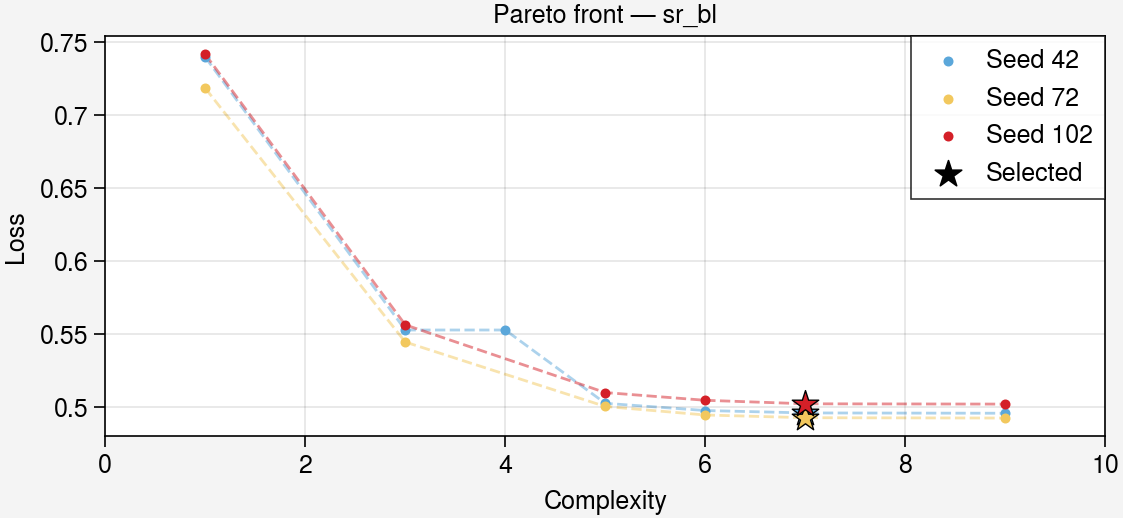

Complexity,Model,Seed 42,Seed 72,Seed 102
7,SR-BL,$(\mathrm{B_L} + 0.2988)^{3} + 0.136$,$(\mathrm{B_L} + 0.2925)^{3} + 0.1445$,$(\mathrm{B_L} + 0.2958)^{3} + 0.1458$


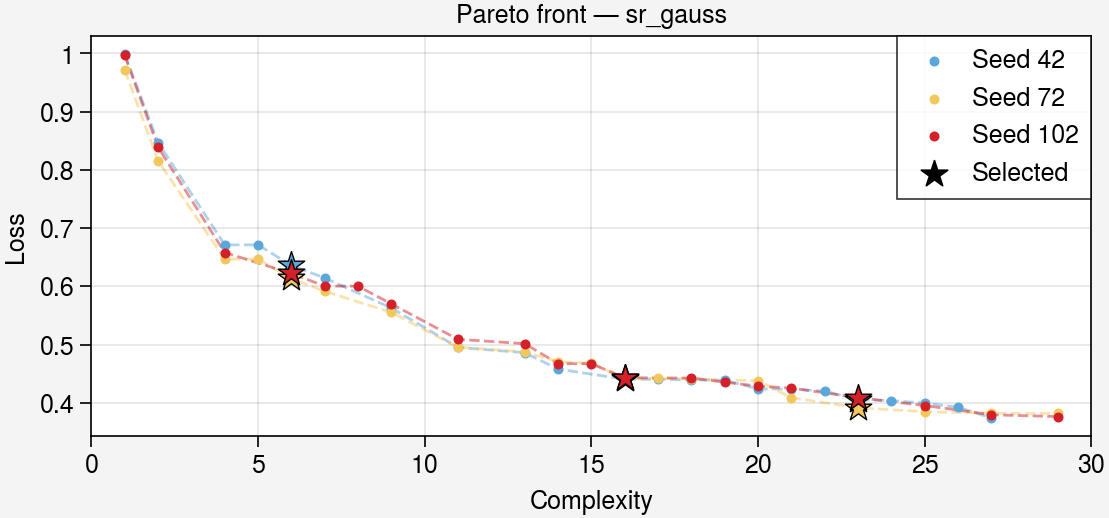

Complexity,Model,Seed 42,Seed 72,Seed 102
6,SR-LO,$e^{\widehat{\mathrm{RH}}} - 0.6525$,$e^{\widehat{\mathrm{RH}}} - 0.6528$,$e^{\widehat{\mathrm{RH}}} - 0.6467$
16,SR-MED,"$1.553 \cdot \max(\widehat{\mathrm{RH}}, \widehat{\theta}_{e} - 1.469 \cdot {\widehat{\theta}_{e}^{*}} - 0.3707)^{3}$","$1.576 \cdot \max(\widehat{\mathrm{RH}}, \widehat{\theta}_{e} - 1.472 \cdot {\widehat{\theta}_{e}^{*}} - 0.3762)^{3}$","$1.599 \cdot \max(\widehat{\mathrm{RH}}, \widehat{\theta}_{e} - 1.471 \cdot {\widehat{\theta}_{e}^{*}} - 0.38)^{3}$"
23,SR-HI,"$(- 0.1317 \cdot \max(\mathrm{LF}, \mathrm{SHF}) + 1.313 \cdot \max(\widehat{\mathrm{RH}}, \widehat{\theta}_{e} - 1.363 \cdot {\widehat{\theta}_{e}^{*}} - 0.4223))^{3}$","$\mathrm{LF} + \widehat{\mathrm{RH}}^{3} + 1.541 \cdot \widehat{\theta}_{e} - 1.865 \cdot {\widehat{\theta}_{e}^{*}} - 1.833 \cdot \max(\mathrm{LF}, \mathrm{SHF})$","$2.203 \cdot (- 0.094 \cdot \max(\mathrm{LF}, \mathrm{SHF}) + \max(\widehat{\mathrm{RH}}, \widehat{\theta}_{e} - 1.356 \cdot {\widehat{\theta}_{e}^{*}} - 0.4124))^{3}$"


In [5]:
PARETO_COLORS = ['#5BA7DA', '#F2C85E', '#D42028']

for runname in SRCONFIG['runs']:
    seedframes = load_equations(runname)
    if not seedframes:
        print(f'[{runname}] No equations found — run on cluster')
        continue

    sel = {name: spec for name, spec in SRCONFIG['optimizedeqs'].items()
           if spec['runfrom'] == runname and spec.get('refcomplexity') is not None}
    selcomplexities = sorted({spec['refcomplexity'] for spec in sel.values()})
    seeds_here      = sorted(seedframes.keys())
    allcomplexity   = pd.concat(seedframes.values())['complexity']

    fig, ax = pplt.subplots(refwidth=5, refheight=2)
    ax.format(title=f'Pareto front — {runname}', xlabel='Complexity',
              xlim=(0, allcomplexity.max() + 1), ylabel='Loss')
    for i, seed in enumerate(seeds_here):
        df    = seedframes[seed].sort_values('complexity')
        color = PARETO_COLORS[i % len(PARETO_COLORS)]
        ax.plot(df['complexity'], df['loss'], color=color, alpha=0.5, linewidth=1,
                linestyle='--', zorder=1, label='')
        ax.scatter(df['complexity'], df['loss'], color=color, marker='.', zorder=3,
                   label=f'Seed {seed}')
        for c in selcomplexities:
            row = df[df['complexity'] == c]
            if not row.empty:
                ax.scatter([row['complexity'].values[0]], [row['loss'].values[0]],
                           color=color, edgecolors='k', marker='*',
                           markersize=100, linewidths=0.5, zorder=5)
    ax.scatter([], [], color='k', marker='*', markersize=100, label='Selected')
    ax.legend(loc='ur', ncols=1)
    pplt.show()

    if not selcomplexities:
        continue
    eq_rows = []
    for c in selcomplexities:
        eq_names = [spec['description'] for name, spec in sel.items()
                    if spec['refcomplexity'] == c]
        row = {'Complexity': c, 'Model': ', '.join(eq_names)}
        for seed in seeds_here:
            df    = seedframes[seed]
            match = df[df['complexity'] == c]
            row[f'Seed {seed}'] = prettify(match.iloc[0]['equation']) if not match.empty else '—'
        eq_rows.append(row)
    display(HTML(pd.DataFrame(eq_rows).to_html(escape=False, index=False)))

In [9]:
def load_registry():
    pklpath = os.path.join(MODELSDIR, 'sr', 'optimized_equations.pkl')
    if not os.path.exists(pklpath):
        return {}
    with open(pklpath, 'rb') as f:
        return pickle.load(f)

def prettify_optimized(opt):
    ns = {**SYMBOLS, **FUNCDICT}
    ns.update({k: sp.Float(v) for k, v in opt['constants'].items()})
    try:
        expr = eval(opt['form'], {'__builtins__': {}}, ns)
        expr = _round_numbers(expr, ndigits=4)
        expr = _order_expr(expr)
        return r'$\hat{P} = ' + _latex_expr(expr) + '$'
    except Exception as e:
        return f"{opt['form']}  [render error: {e}]"

registry = load_registry()
rows = []
for name, eqspec in SRCONFIG['optimizedeqs'].items():
    opt = registry.get(name)
    if opt is None:
        rows.append({'Model': eqspec['description'], 
                     #'Form': eqspec['form'],
                     'Train MSE': '—', 'Valid MSE': '—'})
    else:
        rows.append({'Model':     eqspec['description'],
                     'Equation':  prettify_optimized(opt),
                     'Train MSE': f"{opt['train_loss']:.4f}",
                     'Valid MSE': f"{opt['valid_loss']:.4f}"})
display(HTML(pd.DataFrame(rows).to_html(escape=False,index=False)))

Model,Equation,Train MSE,Valid MSE
SR-BL,$\hat{P} = (\mathrm{B_L} + 0.2957)^{3} + 0.1421$,0.4984,0.5017
SR-LO,$\hat{P} = 1.0 \cdot e^{\widehat{\mathrm{RH}}} - 0.6507$,0.6246,0.6214
SR-MED,"$\hat{P} = 1.558 \cdot \max(\widehat{\mathrm{RH}}, \widehat{\theta}_{e} - 1.471 \cdot {\widehat{\theta}_{e}^{*}} - 0.3756)^{3}$",0.4452,0.4522
SR-HI,NaN,—,—


In [8]:
import torch

nn_cfg    = CONFIGS['experiments']['nn']
fieldvars = nn_cfg['runs']['nn_gauss']['fieldvars']
modeldir  = os.path.join('..', CONFIGS['filepaths']['models'].split('monsoon-discovery/')[-1], 'nn')
seeds     = nn_cfg['seeds']

kernel_rows = []
for seed in seeds:
    ckpt_path = os.path.join(modeldir, f'nn_gauss_{seed}.pth')
    if not os.path.exists(ckpt_path):
        continue
    state = torch.load(ckpt_path, map_location='cpu')
    if 'state_dict' in state:
        state = state['state_dict']
    mu     = state['kernel.function.mu'].numpy()
    logstd = state['kernel.function.logstd'].numpy()
    for i, fv in enumerate(fieldvars):
        kernel_rows.append({
            'Seed':        seed,
            'Variable':    fv,
            'σ_center':    round(float(0.75 + mu[i]*0.25), 4),
            'Δσ (1σ width)': round(float(np.exp(logstd[i])*0.25), 4),
        })

if not kernel_rows:
    print('[warn] No nn_gauss checkpoints found — run on the cluster')
else:
    kdf = pd.DataFrame(kernel_rows)
    summary = kdf.groupby('Variable')[['σ_center','Δσ (1σ width)']].agg(['mean','std']).round(4)
    summary.columns = ['σ_center (mean)', 'σ_center (std)', 'Δσ mean', 'Δσ std']
    display(HTML(summary.to_html()))

,σ_center (mean),σ_center (std),Δσ mean,Δσ std
Variable,,,,
rh,-0.0410,0.1772,0.5374,0.0445
thetae,1.0198,0.0075,0.1459,0.0054
thetaestar,0.7707,0.0016,0.1279,0.0007
